# MDR-TS v2.1
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v2.1
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_8.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

- Spatial Evaluation with the new stations

## 0. Imports

In [14]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import torch

project_root = os.path.abspath("../../")
if project_root not in sys.path:
    sys.path.append(project_root)

from Utils.dashboard import metrics_dashboard

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

def assign_regime(sm):
    if sm < 0.20:
        return 'D'
    elif sm < 0.313:
        return 'T'
    else:
        return 'W'

imports loaded
using: cpu


In [2]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


In [3]:
VERSION = "v2.1"
SUBVERSION = "v2.1"
RUN_NAME = "mdr_ts_v2.1"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v2.1/v2.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_9.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_9.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_9.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_9.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_9.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_9.0/test.csv


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 499

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


In [29]:
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
    'SMAP_sm_pm_interp_ema02',
    'V_rollmin_LST_modis_kobs30',
    'D_sin_DOY', 'G_rain_sum_3d',
    'V_rollmin_G_API_kobs30',
    'G_rain_sum_7d',
    'C_lag_LST_modis_kobs30',
    'C_lag_G_API_kobs1',
    'V_ema_G_API_kobs14',
    'V_rollmean_G_API_kobs14',
    'G_API', 'G_DSLR',
    'SMAP_ampm_diff_interp',
    'V_rollmax_G_API_kobs30',
    'V_ema_G_API_kobs30',
    'V_rollmean_s2_b11_kobs7',
    'V_ema_LST_modis_kobs7',
    'V_rollmean_G_API_kobs7',
    'C_lag_s2_b11_kobs30',
    'A_d_E_SAR_diff_kobs14',
    'C_lag_LST_modis_kobs6',
    'A_d_LST_modis_kobs14',
    'A_d_SMAP_sm_interp_kobs14',
    'V_rollstd_SMAP_sm_interp_kobs30',
    'SMAP_sm_interp_grad7',
    'year_frac', 'sin_year', 'cos_year',
    'API_x_year', 'SMAP_x_year',
    'slope', 'elev', 'K_slope_sin',
    'K_slope_cos', 'K_aspect_cos',
    'J_clay_wfrac_b0', 'J_sand_wfrac_b0'
    ]

DARRINGTON_CLUSTER = ['Darrington',
                      'BeaverPass_WA_990',
                      'MartenRidge_WA_999',
                      'MFNooksack_WA_1011',
                      'USCRN_Darrington_21_NNE']

QUINAULT_CLUSTER = ['Quinault',
                    'Touchet_WA_824',
                    'USCRN_Corvallis_10_SSW',
                    'USCRN_Quinault_4_NE']

SOURDOUGHGULCH_CLUSTER = ['SourdoughGulch_WA_985',
                          'USCRN_Dillon_18_WSW',
                          'SCAN_ConradAgRc',
                          'USCRN_Coos_Bay_8_SW']

SPOKANE_CLUSTER = ['Spokane',
                   'CayusePass_WA',
                   'Paradise_WA',
                   'BurntMountain_WA',
                   'HartsPass_WA_515',
                   'RainyPass_WA_711',
                   'USCRN_Arco_17_SW',
                   'USCRN_John_Day_35_WNW',
                    'USCRN_Murphy_10_W',
                    'USCRN_Riley_10_WSW',
                    'USCRN_Spokane_17_SSW',
                    'USCRN_St_Mary_1_SSW',
                    'SCAN_CookFarmFieldD',
                    'SCAN_JordanValleyCwma',
                    'SCAN_Lind_1',
                    'SCAN_OrchardRangeSite',
                    'SCAN_TableMountain',
                    'SCAN_Violett']

ORIGINAL_CLUSTER = ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']

ALL_CLUSTERS = {
    'Original': ORIGINAL_CLUSTER,
    'Darrington': DARRINGTON_CLUSTER,
    'Quinault': QUINAULT_CLUSTER,
    'SourdoughGulch_WA_985': SOURDOUGHGULCH_CLUSTER,
    'Spokane': SPOKANE_CLUSTER,
}

In [8]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics):
    print(f"{'METRIC':<15} | {'VALUE':<10}")
    print("-" * 28)
    for k, v in metrics.items():
        val_str = f"{v:,}" if isinstance(v, int) else f"{v:+.5f}"
        print(f"{k:<15} | {val_str:<10}")

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [9]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     29362
  stations: ['BeaverPass_WA_990', 'BurntMountain_WA', 'CayusePass_WA', 'Darrington', 'HartsPass_WA_515', 'MFNooksack_WA_1011', 'MartenRidge_WA_999', 'Paradise_WA', 'Quinault', 'RainyPass_WA_711', 'SCAN_ConradAgRc', 'SCAN_CookFarmFieldD', 'SCAN_JordanValleyCwma', 'SCAN_Lind_1', 'SCAN_OrchardRangeSite', 'SCAN_TableMountain', 'SCAN_Violett', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824', 'USCRN_Arco_17_SW', 'USCRN_Corvallis_10_SSW', 'USCRN_Darrington_21_NNE', 'USCRN_Dillon_18_WSW', 'USCRN_John_Day_35_WNW', 'USCRN_Murphy_10_W', 'USCRN_Quinault_4_NE', 'USCRN_Riley_10_WSW', 'USCRN_Spokane_17_SSW', 'USCRN_St_Mary_1_SSW']
  date range: 2017-01-01 -- 2020-12-31

VAL
  rows:     13637
  stations: ['BeaverPass_WA_990', 'BurntMountain_WA', 'CayusePass_WA', 'Darrington', 'HartsPass_WA_515', 'MartenRidge_WA_999', 'Paradise_WA', 'Quinault', 'RainyPass_WA_711', 'SCAN_ConradAgRc', 'SCAN_CookFarmFieldD', 'SCAN_JordanValleyCwma', 'SCAN_Lind_1', 'SCAN_

## Model

In [21]:
import joblib

MODEL_PATH = r'/Users/jbalkovec/Desktop/MDR/Models/TemporalSpatial/v1/BEST_MODEL/rf.pkl'

data = joblib.load(MODEL_PATH)

model = data['model']
features_from_file = data['features']
weights_from_file = data['weights']

print(f"model type: {type(model).__name__}")
print(f"features in file: {len(features_from_file)}")
print(f"weights shape: {weights_from_file.shape if hasattr(weights_from_file, 'shape') else len(weights_from_file)}")

model type: RandomForestRegressor
features in file: 37
weights shape: (9588,)


In [22]:
X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print(f"X_test shape: {X_test.shape}, missing: {X_test.isnull().sum().sum()}")

y_pred = model.predict(X_test)

print(f"Predictions range: [{y_pred.min():.4f}, {y_pred.max():.4f}]")
print(f"Ground truth range: [{y_test.min():.4f}, {y_test.max():.4f}]")

X_test shape: (20166, 37), missing: 306158
Predictions range: [0.0289, 0.3287]
Ground truth range: [0.0000, 0.4730]


In [23]:
test_results = test_df[KEEP_META_COLS + [TARGET_COL]].copy()
test_results['pred'] = y_pred
test_results['error'] = test_results[TARGET_COL] - test_results['pred']

print(f"Results shape: {test_results.shape}")
print(test_results.head())

Results shape: (20166, 7)
              station_id        date  longitude   latitude  soil_moisture_5cm  \
0             Darrington  2023-01-01    -121.45  48.540000              0.294   
1               Quinault  2023-01-01    -123.81  47.510000              0.239   
2  SourdoughGulch_WA_985  2023-01-01    -117.40  46.233333              0.317   
3               Quinault  2023-01-02    -123.81  47.510000              0.234   
4             Darrington  2023-01-02    -121.45  48.540000              0.281   

       pred     error  
0  0.303913 -0.009913  
1  0.264447 -0.025447  
2  0.310126  0.006874  
3  0.264997 -0.030997  
4  0.302830 -0.021830  


In [25]:
station_metrics = []

for station in sorted(test_results['station_id'].unique()):
    mask = test_results['station_id'] == station
    y_true_station = test_results.loc[mask, TARGET_COL]
    y_pred_station = test_results.loc[mask, 'pred']

    metrics = get_metrics_dict(y_true_station, y_pred_station)
    metrics['station'] = station
    station_metrics.append(metrics)

metrics_df = pd.DataFrame(station_metrics)

cols = ['station'] + [c for c in metrics_df.columns if c != 'station']
metrics_df = metrics_df[cols]

print("\n=== PER-STATION METRICS ===\n")
print(metrics_df.to_string(index=False))

print("\n=== DETAILED BREAKDOWN ===\n")
for station in sorted(test_results['station_id'].unique()):
    mask = test_results['station_id'] == station
    y_true_station = test_results.loc[mask, TARGET_COL]
    y_pred_station = test_results.loc[mask, 'pred']

    metrics = get_metrics_dict(y_true_station, y_pred_station, prefix="")
    print(f"\n{station}")
    print("-" * 40)
    neat_print(metrics)


=== PER-STATION METRICS ===

                station    n        r2      mae     rmse   ubrmse      bias   med_ae   p90_ae   q05_err   q50_err   q95_err
      BeaverPass_WA_990  313 -0.229271 0.095582 0.124959 0.113718 -0.051796 0.052601 0.225311 -0.229131 -0.010769  0.109092
       BurntMountain_WA  491 -0.320240 0.067815 0.076319 0.064978 -0.040031 0.066568 0.109434 -0.108268 -0.062066  0.129835
          CayusePass_WA  764 -0.517457 0.135243 0.165425 0.125248  0.108066 0.135640 0.272211 -0.056137  0.135640  0.290561
             Darrington  999  0.889777 0.024604 0.031019 0.025930 -0.017024 0.021054 0.052913 -0.060637 -0.015719  0.024484
       HartsPass_WA_515  239 -2.014902 0.209132 0.216770 0.124585 -0.177391 0.236889 0.246746 -0.247263 -0.236889  0.142331
     MFNooksack_WA_1011    5  0.000000 0.237972 0.237972 0.000101 -0.237972 0.237930 0.238095 -0.238099 -0.237930 -0.237864
     MartenRidge_WA_999  505 -1.052986 0.139113 0.154079 0.108484 -0.109415 0.133397 0.237592 -0.24137

In [ ]:
def get_cluster_name(station):
    for cluster_name, stations in ALL_CLUSTERS.items():
        if station in stations:
            return cluster_name
    return 'Unknown'

metrics_df['cluster'] = metrics_df['station'].apply(get_cluster_name)

cluster_metrics = []

for cluster_name in sorted(ALL_CLUSTERS.keys()):
    stations_in_cluster = ALL_CLUSTERS[cluster_name]
    mask = test_results['station_id'].isin(stations_in_cluster)

    if mask.sum() == 0:
        continue

    y_true_cluster = test_results.loc[mask, TARGET_COL]
    y_pred_cluster = test_results.loc[mask, 'pred']

    metrics = get_metrics_dict(y_true_cluster, y_pred_cluster)
    metrics['cluster'] = cluster_name
    metrics['num_stations'] = sum(1 for s in stations_in_cluster if s in test_results['station_id'].unique())
    cluster_metrics.append(metrics)

cluster_df = pd.DataFrame(cluster_metrics)

cols = ['cluster', 'num_stations'] + [c for c in cluster_df.columns if c not in ['cluster', 'num_stations']]
cluster_df = cluster_df[cols]

print("\n=== CLUSTER-LEVEL METRICS ===\n")
print(cluster_df.to_string(index=False))

print("\n=== DETAILED CLUSTER BREAKDOWN ===\n")
for cluster_name in sorted(ALL_CLUSTERS.keys()):
    stations_in_cluster = ALL_CLUSTERS[cluster_name]
    mask = test_results['station_id'].isin(stations_in_cluster)

    if mask.sum() == 0:
        continue

    y_true_cluster = test_results.loc[mask, TARGET_COL]
    y_pred_cluster = test_results.loc[mask, 'pred']

    metrics = get_metrics_dict(y_true_cluster, y_pred_cluster, prefix="")
    print(f"\n{cluster_name} ({mask.sum()} samples from {sum(1 for s in stations_in_cluster if s in test_results['station_id'].unique())} stations)")
    print("-" * 50)
    neat_print(metrics)


=== CLUSTER-LEVEL METRICS ===

              cluster  num_stations     n        r2      mae     rmse   ubrmse      bias   med_ae   p90_ae   q05_err   q50_err  q95_err
           Darrington             5  2628 -0.244405 0.082774 0.113475 0.113470 -0.001032 0.046245 0.208623 -0.210676 -0.007876 0.207411
             Original             5  4016  0.832805 0.028216 0.038503 0.038503 -0.000102 0.021540 0.059230 -0.061163 -0.000123 0.058210
             Quinault             4  2558 -2.181822 0.104789 0.142905 0.101029  0.101070 0.060027 0.249669 -0.012550  0.058875 0.295743
SourdoughGulch_WA_985             4  2218 -1.849956 0.113141 0.147286 0.112514  0.095046 0.083886 0.241038 -0.070773  0.069104 0.288407
              Spokane            18 12762 -0.082003 0.079499 0.109980 0.106958  0.025604 0.056095 0.210099 -0.100299  0.005499 0.241225

=== DETAILED CLUSTER BREAKDOWN ===


Darrington (2628 samples from 5 stations)
--------------------------------------------------
METRIC          | VAL

In [32]:
overall = get_metrics_dict(test_results[TARGET_COL], test_results['pred'])
overall['cluster'] = 'ALL'
overall['num_stations'] = test_results['station_id'].nunique()

overall_df = pd.DataFrame([overall])

cols = ['cluster', 'num_stations'] + [c for c in overall_df.columns if c not in ['cluster', 'num_stations']]
overall_df = overall_df[cols]

print("\n=== OVERALL METRICS ===\n")
print(overall_df.to_string(index=False))

# Detailed breakdown
print("\n=== DETAILED OVERALL BREAKDOWN ===\n")
metrics = get_metrics_dict(test_results[TARGET_COL], test_results['pred'], prefix="")
print(f"ALL STATIONS ({test_results.shape[0]} samples from {test_results['station_id'].nunique()} stations)")
print("-" * 50)
neat_print(metrics)


=== OVERALL METRICS ===

cluster  num_stations     n        r2      mae     rmse   ubrmse     bias   med_ae   p90_ae   q05_err  q50_err  q95_err
    ALL            31 20166 -0.132592 0.086834 0.119621 0.112966 0.039343 0.057627 0.221161 -0.109596 0.015254 0.249719

=== DETAILED OVERALL BREAKDOWN ===

ALL STATIONS (20166 samples from 31 stations)
--------------------------------------------------
METRIC          | VALUE     
----------------------------
n               | 20,166    
r2              | -0.13259  
mae             | +0.08683  
rmse            | +0.11962  
ubrmse          | +0.11297  
bias            | +0.03934  
med_ae          | +0.05763  
p90_ae          | +0.22116  
q05_err         | -0.10960  
q50_err         | +0.01525  
q95_err         | +0.24972  


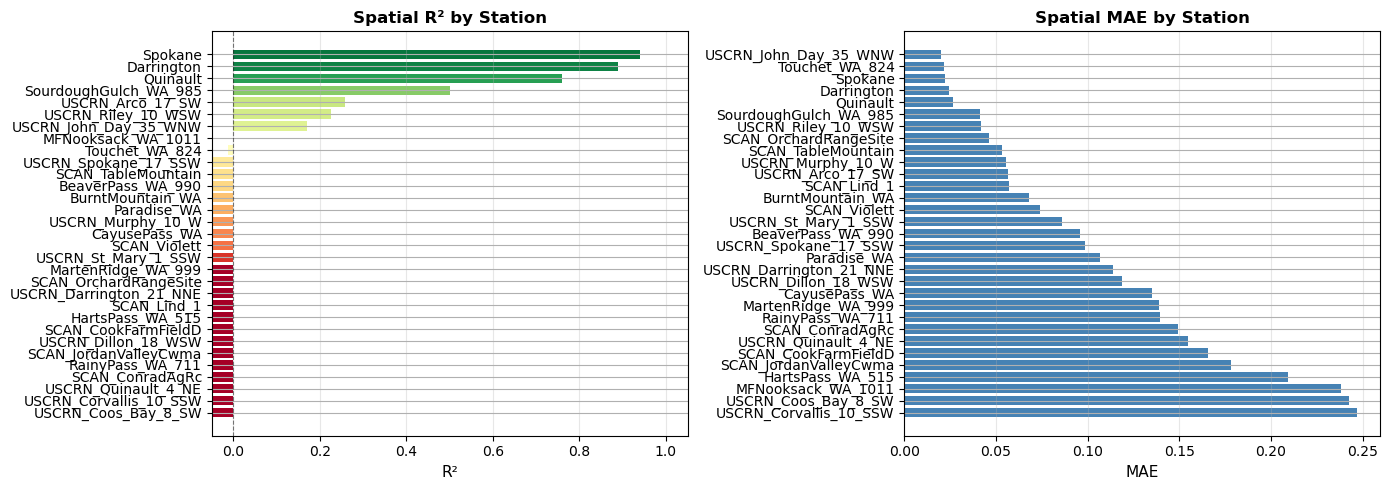

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
metrics_sorted = metrics_df.sort_values('r2', ascending=True)
colors = [plt.cm.RdYlGn(x) for x in (metrics_sorted['r2'] + 1) / 2]
ax.barh(metrics_sorted['station'], metrics_sorted['r2'], color=colors)
ax.set_xlabel('R²', fontsize=11)
ax.set_title('Spatial R² by Station', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(-0.05, 1.05)

ax = axes[1]
metrics_sorted_mae = metrics_df.sort_values('mae', ascending=False)
ax.barh(metrics_sorted_mae['station'], metrics_sorted_mae['mae'], color='steelblue')
ax.set_xlabel('MAE', fontsize=11)
ax.set_title('Spatial MAE by Station', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

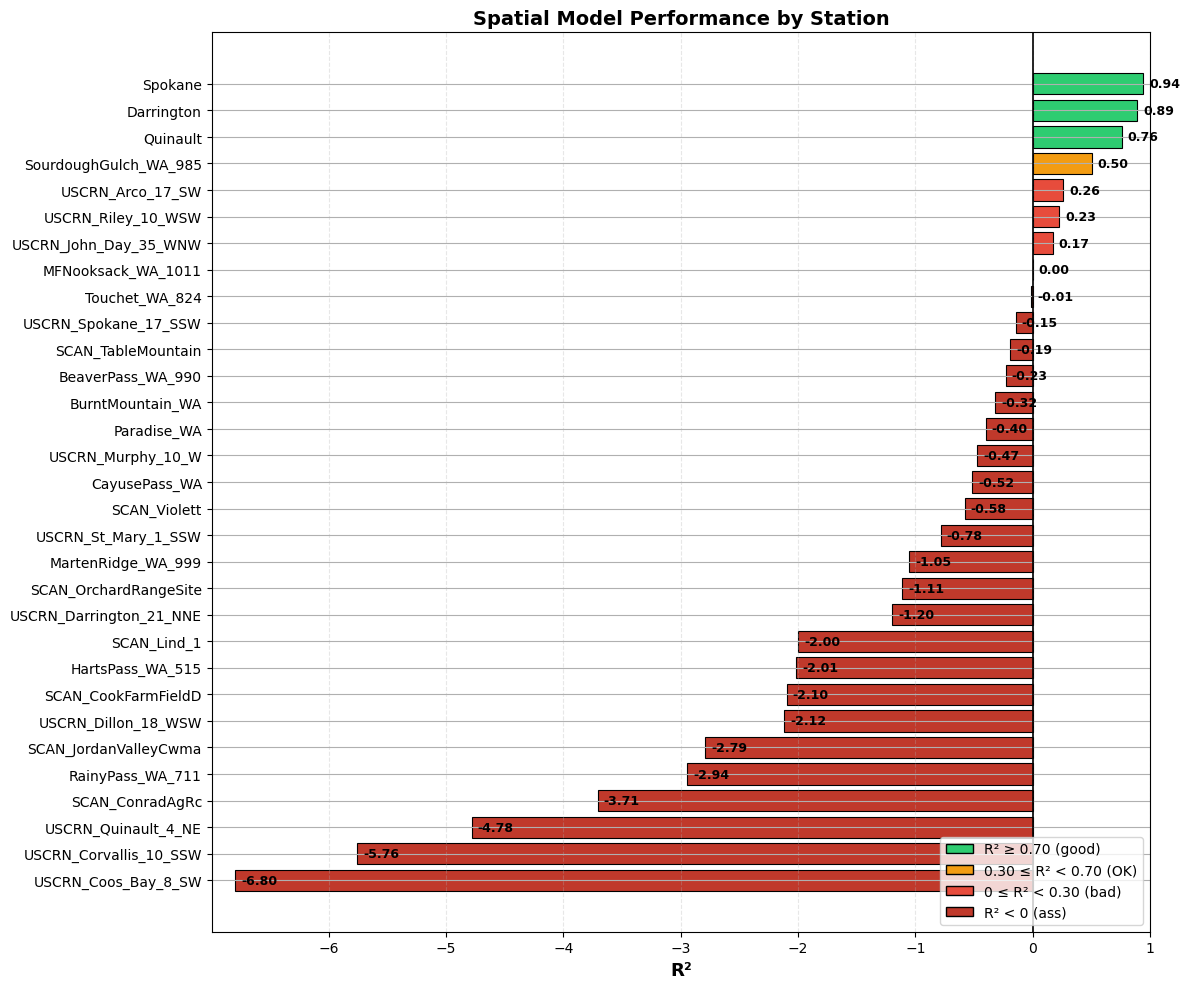

In [38]:
fig, ax = plt.subplots(figsize=(12, 10))

metrics_sorted = metrics_df.sort_values('r2', ascending=True)

def get_color(r2_val):
    if r2_val >= 0.7:
        return '#2ecc71'  # Green
    elif r2_val >= 0.3:
        return '#f39c12'  # Orange
    elif r2_val >= 0:
        return '#e74c3c'  # Red
    else:
        return '#c0392b'  # Dark red

colors = [get_color(r2) for r2 in metrics_sorted['r2']]

ax.barh(metrics_sorted['station'], metrics_sorted['r2'], color=colors, edgecolor='black', linewidth=0.8)
ax.set_xlabel('R²', fontsize=13, fontweight='bold')
ax.set_title('Spatial Model Performance by Station', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linestyle='-', linewidth=1.2)
ax.set_xlim(min(metrics_sorted['r2'].min() - 0.2, -3), 1.0)
ax.grid(axis='x', alpha=0.3, linestyle='--')

for i, (station, r2) in enumerate(zip(metrics_sorted['station'], metrics_sorted['r2'])):
    ax.text(r2 + 0.05, i, f'{r2:.2f}', va='center', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='R² ≥ 0.70 (good)'),
    Patch(facecolor='#f39c12', edgecolor='black', label='0.30 ≤ R² < 0.70 (OK)'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='0 ≤ R² < 0.30 (bad)'),
    Patch(facecolor='#c0392b', edgecolor='black', label='R² < 0 (ass)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

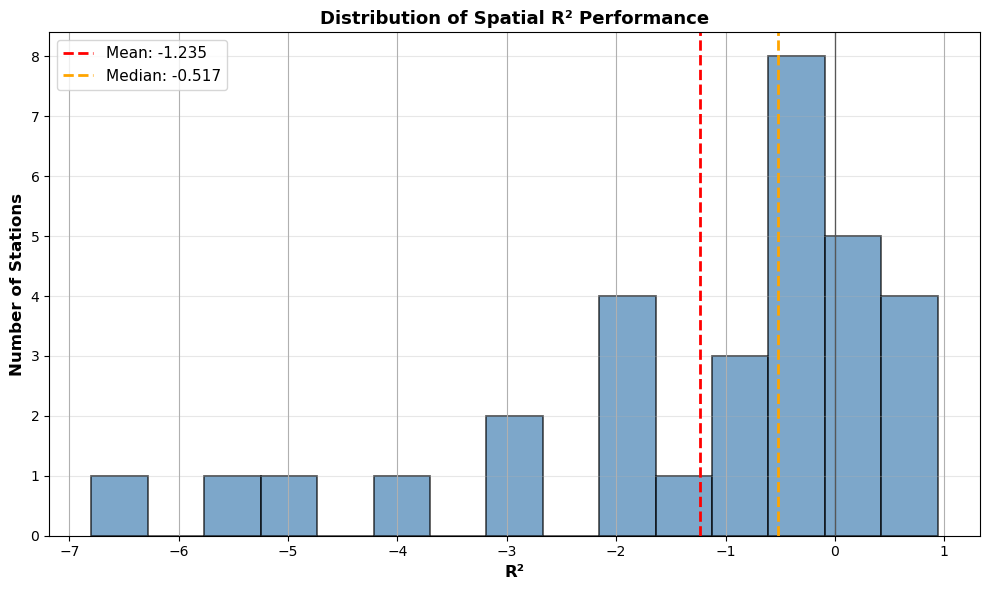

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(metrics_df['r2'], bins=15, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.2)
ax.axvline(metrics_df['r2'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {metrics_df["r2"].mean():.3f}')
ax.axvline(metrics_df['r2'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {metrics_df["r2"].median():.3f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax.set_xlabel('R²', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Stations', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Spatial R² Performance', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

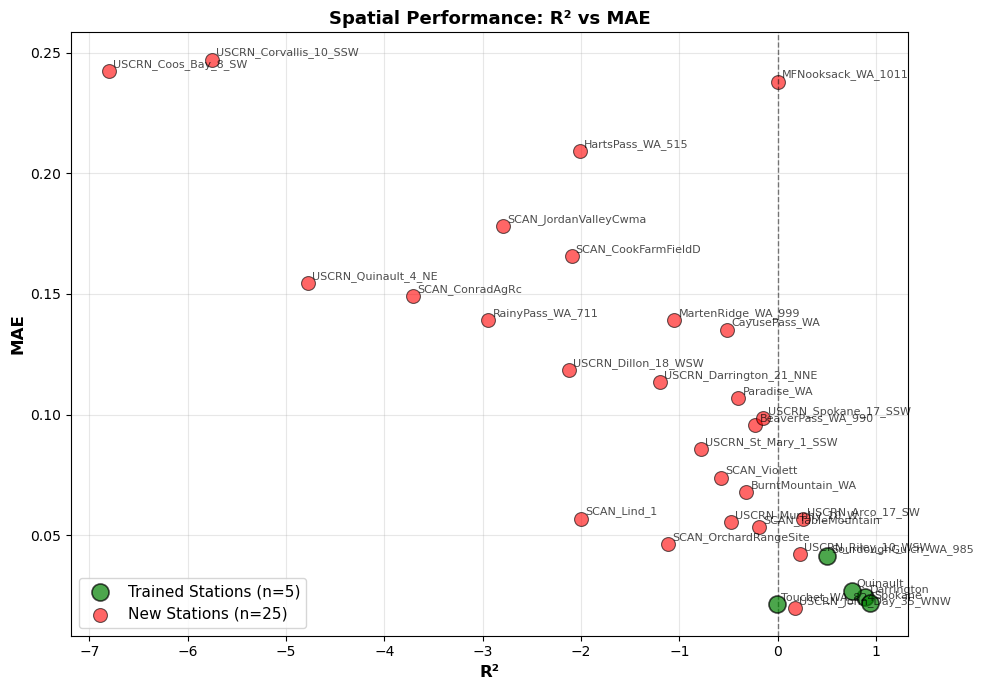

In [43]:
fig, ax = plt.subplots(figsize=(10, 7))

is_trained = metrics_df['station'].isin(['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824'])

trained = metrics_df[is_trained]
new = metrics_df[~is_trained]

ax.scatter(trained['r2'], trained['mae'], s=150, alpha=0.7, color='green', edgecolor='black', linewidth=1.2, label='Trained Stations (n=5)', zorder=3)
ax.scatter(new['r2'], new['mae'], s=100, alpha=0.6, color='red', edgecolor='black', linewidth=0.8, label='New Stations (n=25)', zorder=2)

for idx, row in metrics_df.iterrows():
    ax.annotate(row['station'], (row['r2'], row['mae']), fontsize=8, alpha=0.7,
                xytext=(3, 3), textcoords='offset points')

ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('R²', fontsize=12, fontweight='bold')
ax.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax.set_title('Spatial Performance: R² vs MAE', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

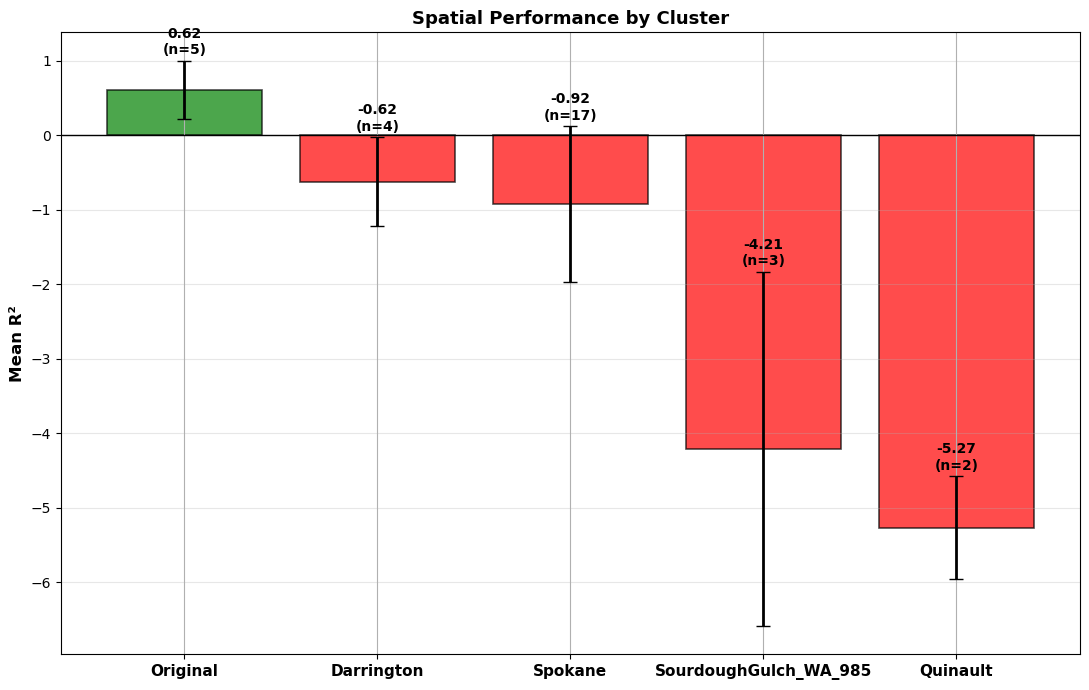

In [44]:
fig, ax = plt.subplots(figsize=(11, 7))

cluster_r2 = metrics_df.groupby('cluster')['r2'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

x = np.arange(len(cluster_r2))
bars = ax.bar(x, cluster_r2['mean'], yerr=cluster_r2['std'],
              capsize=5, color=['green' if m > 0 else 'red' for m in cluster_r2['mean']],
              alpha=0.7, edgecolor='black', linewidth=1.2, error_kw={'elinewidth': 2})

ax.set_xticks(x)
ax.set_xticklabels(cluster_r2.index, fontsize=11, fontweight='bold')
ax.set_ylabel('Mean R²', fontsize=12, fontweight='bold')
ax.set_title('Spatial Performance by Cluster', fontsize=13, fontweight='bold')
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.grid(axis='y', alpha=0.3)

for i, (mean, std, count) in enumerate(zip(cluster_r2['mean'], cluster_r2['std'], cluster_r2['count'])):
    ax.text(i, mean + std + 0.05, f'{mean:.2f}\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

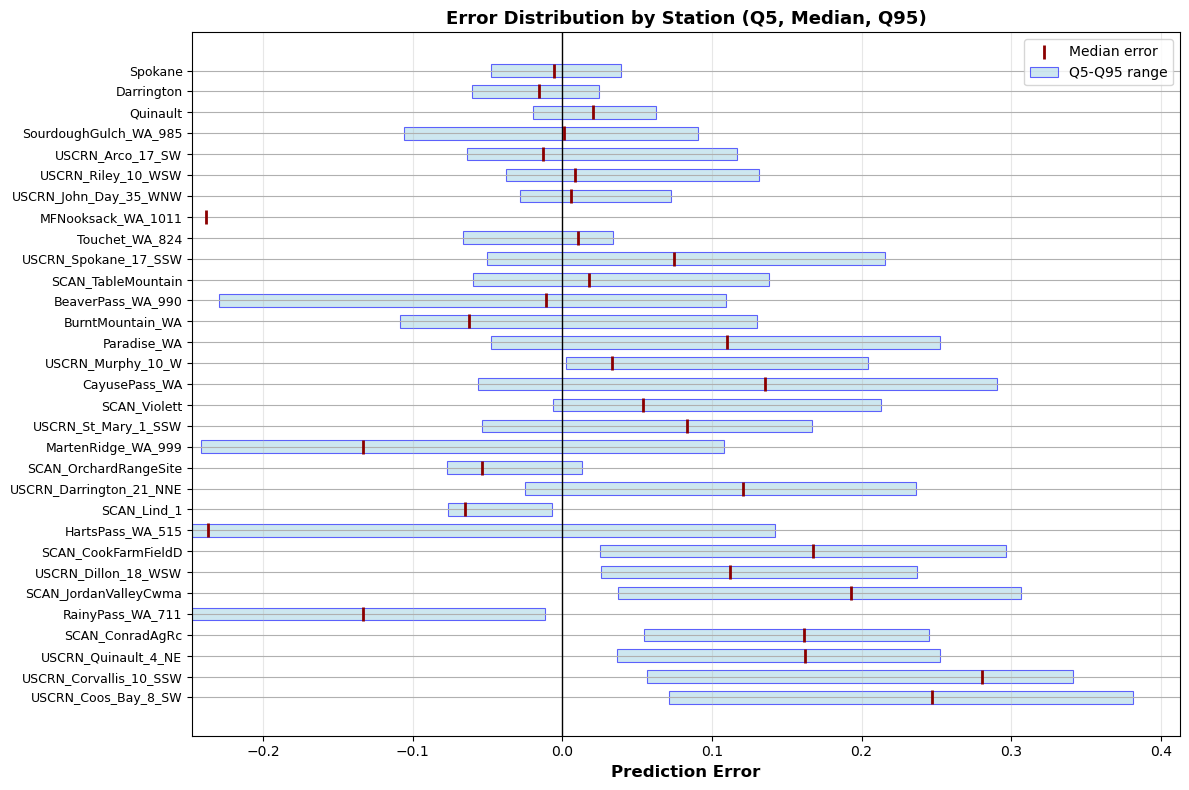

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

metrics_sorted = metrics_df.sort_values('r2', ascending=True)

y_pos = np.arange(len(metrics_sorted))
median_err = metrics_sorted['q50_err'].values
q5_err = metrics_sorted['q05_err'].values
q95_err = metrics_sorted['q95_err'].values

ax.barh(y_pos, q95_err - q5_err, left=q5_err, height=0.6, color='lightblue', alpha=0.6, edgecolor='blue', linewidth=0.8, label='Q5-Q95 range')

ax.scatter(median_err, y_pos, color='darkred', s=100, zorder=3, marker='|', linewidths=2, label='Median error')

ax.set_yticks(y_pos)
ax.set_yticklabels(metrics_sorted['station'], fontsize=9)
ax.set_xlabel('Prediction Error', fontsize=12, fontweight='bold')
ax.set_title('Error Distribution by Station (Q5, Median, Q95)', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

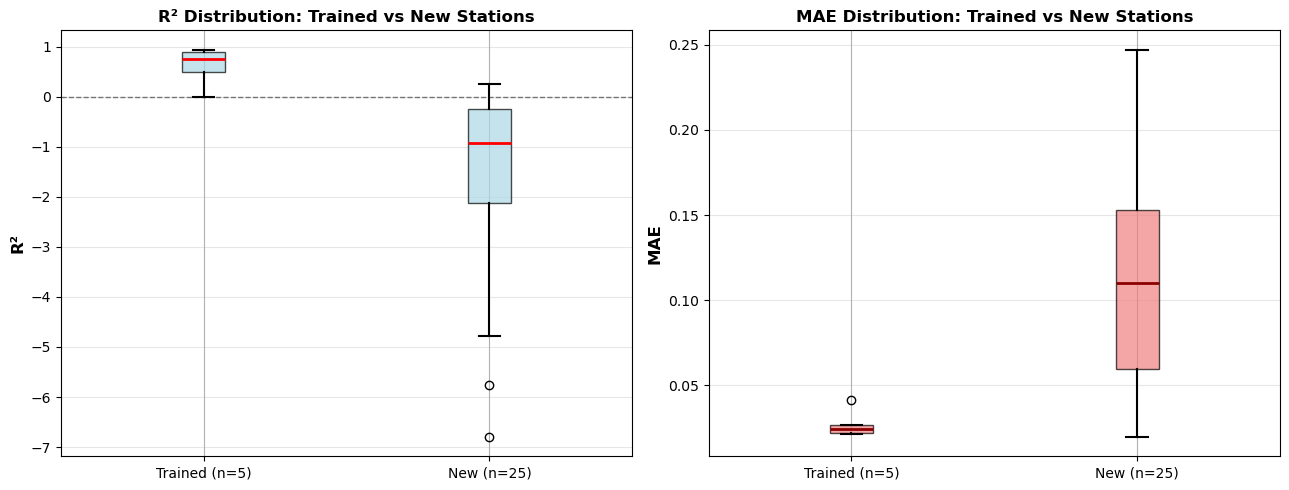

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

trained_stations = ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
is_trained = metrics_df['station'].isin(trained_stations)

trained_metrics = metrics_df[is_trained]
new_metrics = metrics_df[~is_trained]

ax1.boxplot([trained_metrics['r2'].values, new_metrics['r2'].values],
            labels=['Trained (n=5)', 'New (n=25)'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5))

ax1.set_ylabel('R²', fontsize=12, fontweight='bold')
ax1.set_title('R² Distribution: Trained vs New Stations', fontsize=12, fontweight='bold')
ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.grid(axis='y', alpha=0.3)

ax2.boxplot([trained_metrics['mae'].values, new_metrics['mae'].values],
            labels=['Trained (n=5)', 'New (n=25)'],
            patch_artist=True,
            boxprops=dict(facecolor='lightcoral', alpha=0.7),
            medianprops=dict(color='darkred', linewidth=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5))

ax2.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax2.set_title('MAE Distribution: Trained vs New Stations', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
print("\n=== PERFORMANCE SUMMARY ===\n")
print(f"TRAINED STATIONS (Original 5):")
print(f"  Mean R²: {trained_metrics['r2'].mean():.3f}")
print(f"  Mean MAE: {trained_metrics['mae'].mean():.4f}")
print(f"\nNEW STATIONS (25 unseen locations):")
print(f"  Mean R²: {new_metrics['r2'].mean():.3f}")
print(f"  Mean MAE: {new_metrics['mae'].mean():.4f}")
print(f"\nGAP (trained - new):")
print(f"  R² gap: {trained_metrics['r2'].mean() - new_metrics['r2'].mean():.3f}")
print(f"  MAE gap: {new_metrics['mae'].mean() - trained_metrics['mae'].mean():.4f}")


=== PERFORMANCE SUMMARY ===

TRAINED STATIONS (Original 5):
  Mean R²: 0.615
  Mean MAE: 0.0272

NEW STATIONS (25 unseen locations):
  Mean R²: -1.591
  Mean MAE: 0.1188

GAP (trained - new):
  R² gap: 2.206
  MAE gap: 0.0916


---

_Jakob Balkovec_